# Figure out what color space cuts can be used to remove the different spectral types, or rather how to separate them out from each other.

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
#import scipy.interpolate as scinterp
import time

sys.path.append('../')
sys.path.append('/Users/BenKaiser/Desktop/radial_velocity_calculations/')

In [2]:
import cal_params as cp
import spec_plot_tools as spt

In [3]:
input_path='/Users/BenKaiser/Desktop/MORDOR_Survey_paper/MORDOR_Survey_forPaper/Goodman_spectra_copy/'
input_file='full_MORDOR_survey_1681141339_fullphotometry_fitparams_massadd.csv'
input_table=Table.read(input_path+input_file)

In [4]:
input_table.pprint()

       name       ...
----------------- ...
MORDOR J0008-2404 ...
  SDSS J0049+2244 ...
MORDOR J0110-5926 ...
MORDOR J0110-5600 ...
MORDOR J0126-4707 ...
  SDSS J0132+1823 ...
MORDOR J0135-6306 ...
       LEHPM 1774 ...
  LSPM J0211+0835 ...
MORDOR J0225-3312 ...
              ... ...
MORDOR J2126-7502 ...
MORDOR J2158+4243 ...
MORDOR J2236-3635 ...
MORDOR J2238-5558 ...
MORDOR J2244+4204 ...
  SDSS J2309+0959 ...
  SDSS J2314+2717 ...
MORDOR J2320-6637 ...
MORDOR J2324-5942 ...
MORDOR J2339+3728 ...
     WD J2356-209 ...
Length = 120 rows


In [5]:
def get_sp_type_table(sp_type=''):
    inds=np.where(input_table['sp_type']==sp_type)
    out_table=input_table[inds]
    return out_table

In [6]:
dc_table=get_sp_type_table(sp_type='DC')
wddm_table=get_sp_type_table(sp_type='WDdM')
dq_table=get_sp_type_table(sp_type='DQpec')
dz_table=get_sp_type_table(sp_type='DZ')
unknown_table=get_sp_type_table(sp_type='??')

In [7]:
table_list=[dc_table,wddm_table,dq_table,dz_table,unknown_table]
sp_type_list=['DC','WDdM','DQpec','DZ','??']

In [8]:
def get_mag(table,band,survey='ps1'):
    try:
        mags=table[survey+'_'+band+'_mag']
        errs=table[survey+'_'+band+'_mag_error']
    except KeyError:
        mags=table[survey+'_'+band+'_mean_psf_mag']
        errs=table[survey+'_'+band+'_mean_psf_mag_error']

    return mags, errs

In [9]:
def plot_color_color(table,colorlist1,colorlist2,plot_color='k',label=''):
    """
    plot band1-band2 on x , band3-band4 on y
    colorlist1: [[band1,survey1],[band2,survey2]]
    colorlist2:[[band3,survey3],[band4,survey4]]
    """
    def get_color(colorlist):
        mag_list=[]
        err_list=[]
        for item in colorlist:
            #print('item',item,item[0])
            mag, err=get_mag(table,item[0],survey=item[1])
            mag_list.append(mag)
            err_list.append(err)
        return mag_list, err_list
    mag_list1, err_list1=get_color(colorlist1)
    mag_list2, err_list2=get_color(colorlist2)
    #print('err_list1',err_list1)
    #print('err_list2',err_list2)
    max_err=np.argmax(np.sqrt(err_list1[0]**2+err_list1[1]**2))
    max_err2=np.argmax(np.sqrt(err_list2[0]**2+err_list2[1]**2))
    print(((mag_list2[0]-mag_list2[1])+3*np.sqrt(err_list2[0]**2+err_list2[1]**2))[max_err2])
    print(table['name'][max_err2])
    #print('max_err vals',err_list1[0][max_err],err_list1[1][max_err])
    #print( np.nanmax(np.sqrt(err_list1[0]**2+err_list1[1]**2)),np.max(np.sqrt(err_list1[0]**2+err_list1[1]**2)))
    #plt.scatter(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],color=plot_color,label=label)
    plt.errorbar(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],xerr= np.sqrt(err_list1[0]**2+err_list1[1]**2), yerr=np.sqrt(err_list2[0]**2+err_list2[1]**2) ,color=plot_color,label=label, linestyle='None',marker='o',markersize=cp.plot_marker_size)
    #plt.errorbar(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],xerr= np.sqrt(err_list1[0]**2+err_list1[1]**2), yerr=np.sqrt(err_list2[0]**2+err_list2[1]**2) ,color=plot_color,label=label, linestyle='None',marker=np.str_(cp.sed_type_markers[table['sed_sp_type']]),markersize=cp.plot_marker_size)
    marker_col=table['sed_sp_type'].copy()
    #print(marker_col.mask)
    marker_col[marker_col.mask]=6
    marker_col=np.copy(marker_col)
    #plt.errorbar(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],xerr= np.sqrt(err_list1[0]**2+err_list1[1]**2),\
                 #yerr=np.sqrt(err_list2[0]**2+err_list2[1]**2) ,color=plot_color,label=label, linestyle='None',\
                 #marker=cp.sed_type_markers[marker_col],markersize=cp.plot_marker_size)
    #plt.scatter(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],\
                 #color=plot_color,label=label, linestyle='None',\
                 #marker=cp.sed_type_markers[marker_col],markersize=cp.plot_marker_size)
    #plt.annotate(str(table['name']),xy=(np.copy(mag_list1[0]-mag_list1[1]), np.copy(mag_list2[0]-mag_list2[1])), xycoords='data', xytext=(np.copy(mag_list1[0]-mag_list1[1]), np.copy(mag_list2[0]-mag_list2[1])), textcoords= 'data' , fontsize=8, color =plot_color)
    def make_axis_label(colorlist):
        axis_label=colorlist[0][1]+'_'+colorlist[0][0]+' - '+colorlist[1][1]+'_'+colorlist[1][0]
        return axis_label
    for x,y,s in zip(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],table['name']):
        plt.text(x,y,s,color=plot_color)
    #plt.text(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],table['name'],color=plot_color)
    stringx=make_axis_label(colorlist1)
    stringy=make_axis_label(colorlist2)
    plt.xlabel(stringx)
    plt.ylabel(stringy)

    
    return

### I'm going to try to make a different function that will plot each point one at a time and then based on that it will make the marker shape AND the color. This has to proceed point by point apparently. There's no way around it.

In [10]:
def plot_pointbypoint(table,colorlist1,colorlist2):
    """
    plot band1-band2 on x , band3-band4 on y
    colorlist1: [[band1,survey1],[band2,survey2]]
    colorlist2:[[band3,survey3],[band4,survey4]]
    """
    def get_color(colorlist):
        mag_list=[]
        err_list=[]
        for item in colorlist:
            #print('item',item,item[0])
            mag, err=get_mag(table,item[0],survey=item[1])
            mag_list.append(mag)
            err_list.append(err)
        return mag_list, err_list
    mag_list1, err_list1=get_color(colorlist1)
    mag_list2, err_list2=get_color(colorlist2)
    #print('err_list1',err_list1)
    #print('err_list2',err_list2)
    max_err=np.argmax(np.sqrt(err_list1[0]**2+err_list1[1]**2))
    max_err2=np.argmax(np.sqrt(err_list2[0]**2+err_list2[1]**2))
    #print(((mag_list2[0]-mag_list2[1])+3*np.sqrt(err_list2[0]**2+err_list2[1]**2))[max_err2])
    #print(table['name'][max_err2])
    #print('max_err vals',err_list1[0][max_err],err_list1[1][max_err])
    #print( np.nanmax(np.sqrt(err_list1[0]**2+err_list1[1]**2)),np.max(np.sqrt(err_list1[0]**2+err_list1[1]**2)))
    #plt.scatter(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],color=plot_color,label=label)
    #plt.errorbar(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],xerr= np.sqrt(err_list1[0]**2+err_list1[1]**2), yerr=np.sqrt(err_list2[0]**2+err_list2[1]**2) ,color=plot_color,label=label, linestyle='None',marker='o',markersize=cp.plot_marker_size)
    #plt.errorbar(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],xerr= np.sqrt(err_list1[0]**2+err_list1[1]**2), yerr=np.sqrt(err_list2[0]**2+err_list2[1]**2) ,color=plot_color,label=label, linestyle='None',marker=np.str_(cp.sed_type_markers[table['sed_sp_type']]),markersize=cp.plot_marker_size)
    marker_col=table['sed_sp_type'].copy()
    #print(marker_col.mask)
    marker_col[marker_col.mask]=0
    marker_col=np.copy(marker_col)
    sp_type_col=table['sp_type'].copy()
    #print(sp_type_col)
    sp_type_col.filled('')
    #print(sp_type_col)
    sp_type_col=np.copy(sp_type_col.filled(''))
    #print(sp_type_col)
    for index in range(0,len(table)):
            plt.errorbar(mag_list1[0][index]-mag_list1[1][index],mag_list2[0][index]-mag_list2[1][index],xerr= np.sqrt(err_list1[0][index]**2+err_list1[1][index]**2),\
                 yerr=np.sqrt(err_list2[0][index]**2+err_list2[1][index]**2) ,color=cp.sp_type_colors[sp_type_col[index]],linestyle='None',\
                 marker=cp.sed_type_markers[marker_col[index]],markersize=cp.plot_marker_size)
    #plt.errorbar(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],xerr= np.sqrt(err_list1[0]**2+err_list1[1]**2),\
                 #yerr=np.sqrt(err_list2[0]**2+err_list2[1]**2) ,color=plot_color,label=label, linestyle='None',\
                 #marker=cp.sed_type_markers[marker_col],markersize=cp.plot_marker_size)
    #plt.scatter(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],\
                 #color=plot_color,label=label, linestyle='None',\
                 #marker=cp.sed_type_markers[marker_col],markersize=cp.plot_marker_size)
    #plt.annotate(str(table['name']),xy=(np.copy(mag_list1[0]-mag_list1[1]), np.copy(mag_list2[0]-mag_list2[1])), xycoords='data', xytext=(np.copy(mag_list1[0]-mag_list1[1]), np.copy(mag_list2[0]-mag_list2[1])), textcoords= 'data' , fontsize=8, color =plot_color)
    def make_axis_label(colorlist):
        axis_label=colorlist[0][1]+'_'+colorlist[0][0]+' - '+colorlist[1][1]+'_'+colorlist[1][0]
        return axis_label
    #for x,y,s,sptype in zip(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],table['name'],sp_type_col):
        #plt.text(x,y,s,color=cp.sp_type_colors[sptype])
    #plt.text(mag_list1[0]-mag_list1[1],mag_list2[0]-mag_list2[1],table['name'],color=plot_color)
    stringx=make_axis_label(colorlist1)
    stringy=make_axis_label(colorlist2)
    plt.xlabel(stringx)
    plt.ylabel(stringy)
    
    spt.make_scatter_legend()
    
    return

## Based on testing of PanSTARRS color indices, it appears that i-y vs. r-i separates out the WD+dM binaries and the DQpecs/DZs. However, it is is redundant to have i on both axes, isn't it?

1.8405426912486695
MORDOR J1712+8237
0.33024849061663947
SDSS J1524+2010


/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/numpy/core/_asarray.py:136: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order, subok=True)


1.19198294217036
MORDOR J0424-2001
0.31730766272709887
MORDOR J2053+1302
0.7719748928960871
WD J2356-209
0.36393062107907787
MORDOR J2114-1218


/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/matplotlib/text.py:824: UserWarning: Warning: converting a masked element to nan.
  x = float(self.convert_xunits(self._x))
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/matplotlib/text.py:825: UserWarning: Warning: converting a masked element to nan.
  y = float(self.convert_yunits(self._y))
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/matplotlib/text.py:686: UserWarning: Warning: converting a masked element to nan.
  posx = float(textobj.convert_xunits(textobj._x))
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/matplotlib/text.py:687: UserWarning: Warning: converting a masked element to nan.
  posy = float(textobj.convert_yunits(textobj._y))
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should b

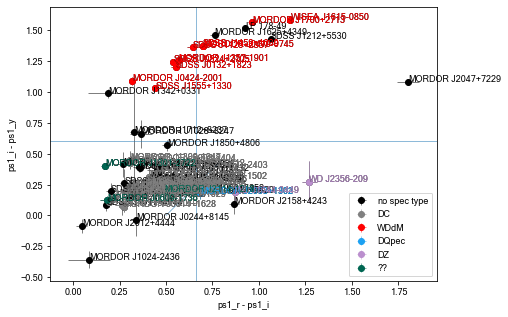

In [11]:
spt.start_mnras_fig(width_cols=2)
plot_color_color(input_table,[['r','ps1'],['i','ps1']],[['i','ps1'],['y','ps1']],plot_color= 'k',label='no spec type')

for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['r','ps1'],['i','ps1']],[['i','ps1'],['y','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.axvline(x=0.66)
plt.axhline(y=0.6)

plt.plot([0.5,0.8],[0.00,0.45])

plt.legend()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/numpy/core/_asarray.py:83: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order)




That's more columns than there are in a MNRAS article... but sure, here you go!


0 o
1 *
2 s
3 ^
4 P
5 X
<class 'list'> [<matplotlib.collections.PathCollection object at 0x7f9f71afaeb8>, <matplotlib.collections.PathCollection object at 0x7f9f71b0d1d0>, <matplotlib.collections.PathCollection object at 0x7f9f71b0d4a8>, <matplotlib.collections.PathCollection object at 0x7f9f71b0d780>, <matplotlib.collections.PathCollection object at 0x7f9f71b0da58>, <matplotlib.collections.PathCollection object at 0x7f9f71aef5c0>]
<class 'list'> [<matplotlib.collections.PathCollection object at 0x7f9f71afaeb8>, <matplotlib.collections.PathCollection object at 0x7f9f71b0d1d0>, <matplotlib.collections.PathCollection object at 0x7f9f71b0d4a8>, <matplotlib.collections.PathCollection object at 0x7f9f71b0d780>, <matplotlib.collections.PathCollection object at 0x7f9f71b0da58>, <matplotlib.collections.PathCollection object at 0x7f9f71aef5c0>, <matplotlib.patches.Patch object at 0x7f9f71aef4a8>, <matplotlib.pat

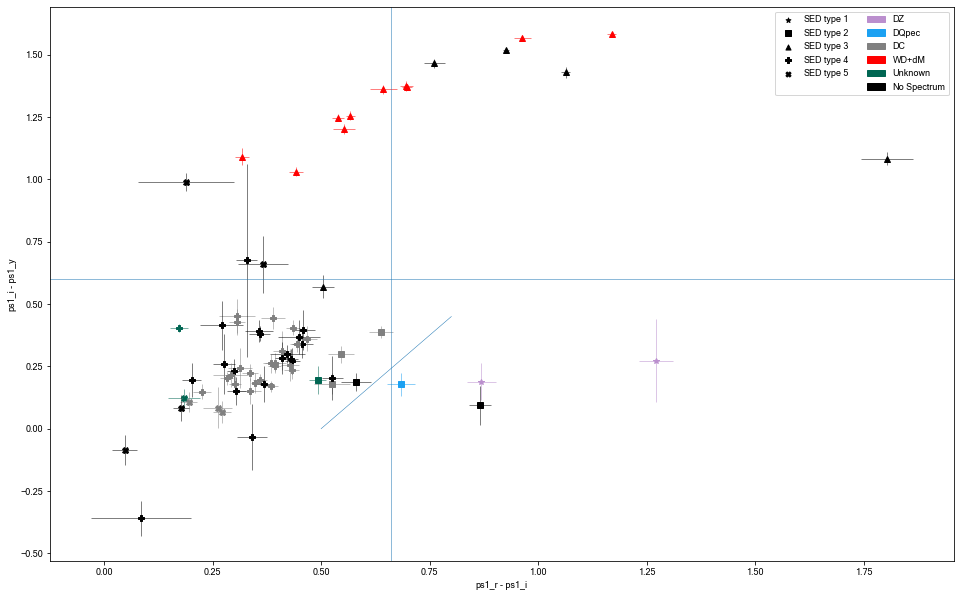

In [12]:
spt.start_mnras_fig(width_cols=4)
plot_pointbypoint(input_table,[['r','ps1'],['i','ps1']],[['i','ps1'],['y','ps1']])


plt.axvline(x=0.66)
plt.axhline(y=0.6)

plt.plot([0.5,0.8],[0.00,0.45])
#spt.make_scatter_legend()
#plt.legend()
plt.show()

0.03850492759987745
WD J2356-209
0.3210695263135117
SDSS J1524+2010
1.0962727288610004
MORDOR J0349+1241
-0.006470909217123982
MORDOR J2053+1302
0.03850492759987745
WD J2356-209
-0.648539833594798
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

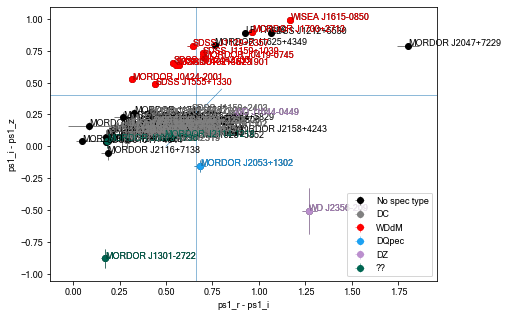

In [13]:
spt.start_mnras_fig(width_cols=2)
plot_color_color(input_table,[['r','ps1'],['i','ps1']],[['i','ps1'],['z','ps1']],plot_color='k',label='No spec type')
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['r','ps1'],['i','ps1']],[['i','ps1'],['z','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.axvline(x=0.66)
plt.axhline(y=0.4)

plt.plot([0.5,0.8],[0.00,0.45])

plt.legend()
plt.show()

0.8387776110906775
SDSS J0750+4651
0.38150611797782474
SDSS J1524+2010
1.0253088674926607
SDSS J0132+1823
--
LEHPM 1774
--
WD J1644-0449
--
MORDOR J0253-3334


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

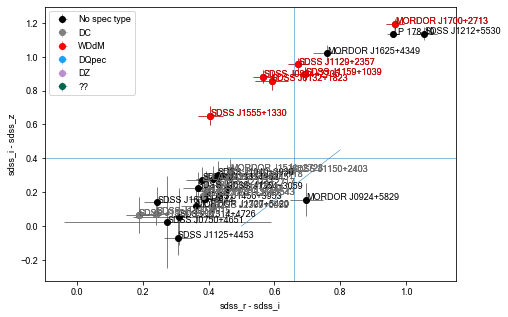

In [14]:
spt.start_mnras_fig(width_cols=2)
plot_color_color(input_table,[['r','sdss'],['i','sdss']],[['i','sdss'],['z','sdss']],plot_color='k',label='No spec type')
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['r','sdss'],['i','sdss']],[['i','sdss'],['z','sdss']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.axvline(x=0.66)
plt.axhline(y=0.4)

plt.plot([0.5,0.8],[0.00,0.45])

plt.legend()
plt.show()



That's more columns than there are in a MNRAS article... but sure, here you go!


0 o
1 *
2 s
3 ^
4 P
5 X
<class 'list'> [<matplotlib.collections.PathCollection object at 0x7f9f71873a20>, <matplotlib.collections.PathCollection object at 0x7f9f71873cf8>, <matplotlib.collections.PathCollection object at 0x7f9f71873fd0>, <matplotlib.collections.PathCollection object at 0x7f9f718002e8>, <matplotlib.collections.PathCollection object at 0x7f9f718005c0>, <matplotlib.collections.PathCollection object at 0x7f9f71800898>]
<class 'list'> [<matplotlib.collections.PathCollection object at 0x7f9f71873a20>, <matplotlib.collections.PathCollection object at 0x7f9f71873cf8>, <matplotlib.collections.PathCollection object at 0x7f9f71873fd0>, <matplotlib.collections.PathCollection object at 0x7f9f718002e8>, <matplotlib.collections.PathCollection object at 0x7f9f718005c0>, <matplotlib.collections.PathCollection object at 0x7f9f71800898>, <matplotlib.patches.Patch object at 0x7f9f71867048>, <matplotlib.pat

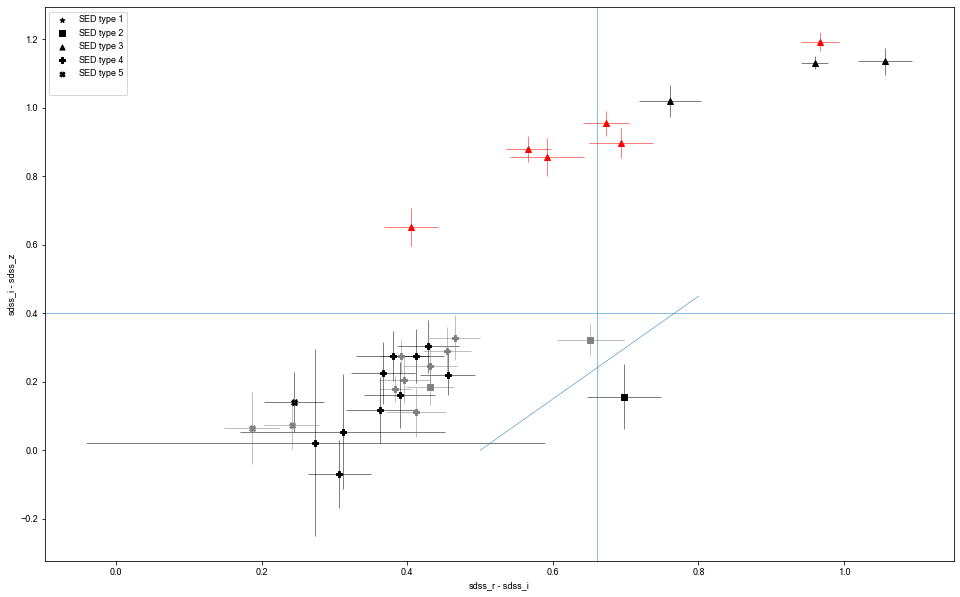

In [15]:
spt.start_mnras_fig(width_cols=4)
plot_pointbypoint(input_table,[['r','sdss'],['i','sdss']],[['i','sdss'],['z','sdss']])
plt.axvline(x=0.66)
plt.axhline(y=0.4)

plt.plot([0.5,0.8],[0.00,0.45])

plt.legend()
plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.33024849061663947
SDSS J1524+2010
1.19198294217036
MORDOR J0424-2001
0.31730766272709887
MORDOR J2053+1302
0.7719748928960871
WD J2356-209
0.36393062107907787
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

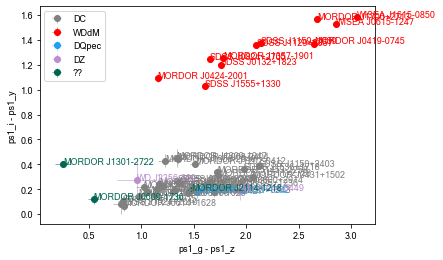

In [16]:
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['g','ps1'],['z','ps1']],[['i','ps1'],['y','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.legend()
plt.show()

0.33024849061663947
SDSS J1524+2010
1.19198294217036
MORDOR J0424-2001
0.31730766272709887
MORDOR J2053+1302
0.7719748928960871
WD J2356-209
0.36393062107907787
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

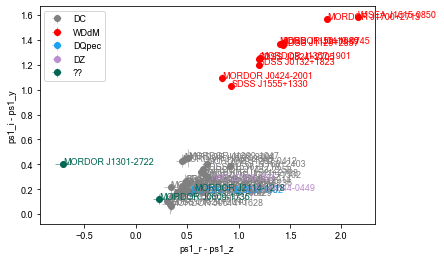

In [17]:
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['r','ps1'],['z','ps1']],[['i','ps1'],['y','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.legend()
plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.33024849061663947
SDSS J1524+2010
1.19198294217036
MORDOR J0424-2001
0.31730766272709887
MORDOR J2053+1302
0.7719748928960871
WD J2356-209
0.36393062107907787
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

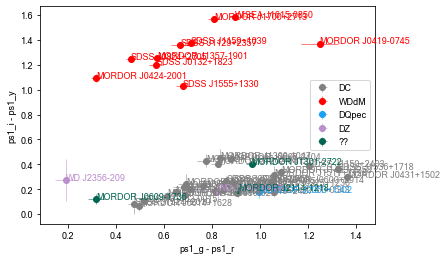

In [18]:
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['g','ps1'],['r','ps1']],[['i','ps1'],['y','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.legend()
plt.show()

0.3210695263135117
SDSS J1524+2010
1.0962727288610004
MORDOR J0349+1241
-0.006470909217123982
MORDOR J2053+1302
0.03850492759987745
WD J2356-209
-0.648539833594798
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

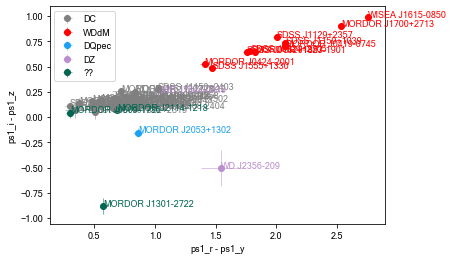

In [19]:
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['r','ps1'],['y','ps1']],[['i','ps1'],['z','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.legend()
plt.show()

## i-z would also work for separating out the WD+dM binaries, but they are closer to the DCs and other isolated white dwarfs


0.3210695263135117
SDSS J1524+2010
1.0962727288610004
MORDOR J0349+1241
-0.006470909217123982
MORDOR J2053+1302
0.03850492759987745
WD J2356-209
-0.648539833594798
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

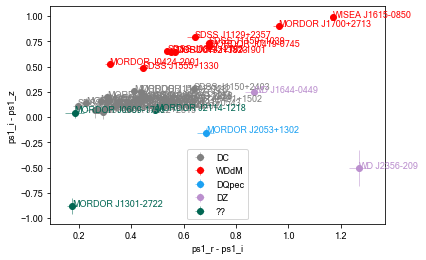

In [20]:
for sp_type in sp_type_list:
    sp_type_table=get_sp_type_table(sp_type=sp_type)
    plot_color_color(sp_type_table,[['r','ps1'],['i','ps1']],[['i','ps1'],['z','ps1']],plot_color=cp.sp_type_colors[sp_type],label=sp_type)
plt.legend()
plt.show()

In [21]:
def make_super_list(survey,band_list):
    ps1_bandlist_list=[]
    ps1_band_list=band_list
    for band in ps1_band_list:
        ps1_bandlist_list.append([band,survey])
    print(ps1_bandlist_list)
    ps1_super_list=[]
    for thing in ps1_bandlist_list:
        for otherthing in ps1_bandlist_list:
            ps1_super_list.append([thing,otherthing])
    print(ps1_super_list)
    for thing in ps1_super_list:
        print(thing)
    return ps1_super_list

In [22]:
ps1_band_list=['g','r','i','z','y']
ps1_super_list=make_super_list('ps1',ps1_band_list)

[['g', 'ps1'], ['r', 'ps1'], ['i', 'ps1'], ['z', 'ps1'], ['y', 'ps1']]
[[['g', 'ps1'], ['g', 'ps1']], [['g', 'ps1'], ['r', 'ps1']], [['g', 'ps1'], ['i', 'ps1']], [['g', 'ps1'], ['z', 'ps1']], [['g', 'ps1'], ['y', 'ps1']], [['r', 'ps1'], ['g', 'ps1']], [['r', 'ps1'], ['r', 'ps1']], [['r', 'ps1'], ['i', 'ps1']], [['r', 'ps1'], ['z', 'ps1']], [['r', 'ps1'], ['y', 'ps1']], [['i', 'ps1'], ['g', 'ps1']], [['i', 'ps1'], ['r', 'ps1']], [['i', 'ps1'], ['i', 'ps1']], [['i', 'ps1'], ['z', 'ps1']], [['i', 'ps1'], ['y', 'ps1']], [['z', 'ps1'], ['g', 'ps1']], [['z', 'ps1'], ['r', 'ps1']], [['z', 'ps1'], ['i', 'ps1']], [['z', 'ps1'], ['z', 'ps1']], [['z', 'ps1'], ['y', 'ps1']], [['y', 'ps1'], ['g', 'ps1']], [['y', 'ps1'], ['r', 'ps1']], [['y', 'ps1'], ['i', 'ps1']], [['y', 'ps1'], ['z', 'ps1']], [['y', 'ps1'], ['y', 'ps1']]]
[['g', 'ps1'], ['g', 'ps1']]
[['g', 'ps1'], ['r', 'ps1']]
[['g', 'ps1'], ['i', 'ps1']]
[['g', 'ps1'], ['z', 'ps1']]
[['g', 'ps1'], ['y', 'ps1']]
[['r', 'ps1'], ['g', 'ps1']]
[['r

In [23]:
def plot_sp_types(colorlist1,colorlist2):
    for sp_type in sp_type_list:
        sp_type_table=get_sp_type_table(sp_type=sp_type)
        plot_color_color(sp_type_table,colorlist1,colorlist2,plot_color=cp.sp_type_colors[sp_type],label=sp_type)
    #plt.legend()
    plt.show()
    return

0.3210695263135117
SDSS J1524+2010
1.0962727288610004
MORDOR J0349+1241
-0.006470909217123982
MORDOR J2053+1302
0.03850492759987745
WD J2356-209
-0.648539833594798
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

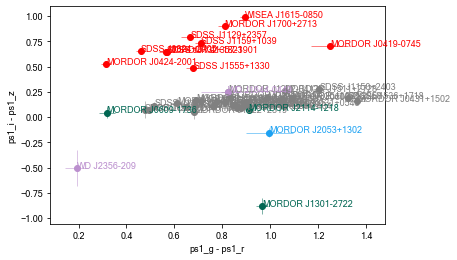

0.33024849061663947
SDSS J1524+2010
1.19198294217036
MORDOR J0424-2001
0.31730766272709887
MORDOR J2053+1302
0.7719748928960871
WD J2356-209
0.36393062107907787
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

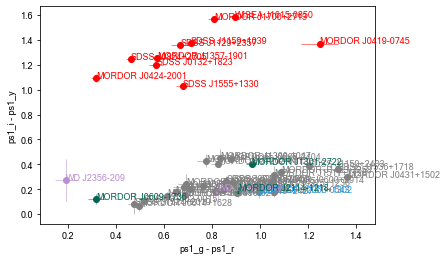

0.17666797602050746
SDSS J1524+2010
-0.8921305914514001
MORDOR J0349+1241
0.29892612447427513
MORDOR J2053+1302
1.0497048787718732
WD J2356-209
1.1134612040028014
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

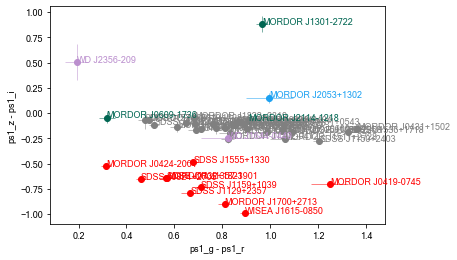

0.3427692106186813
SDSS J1524+2010
0.6738101022417987
MORDOR J0424-2001
0.5002743483456856
MORDOR J2053+1302
1.5083385606645985
WD J2356-209
1.5119013935327352

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values



MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

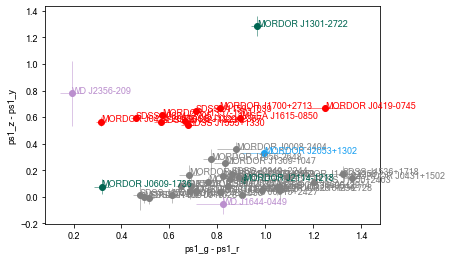

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.16264976625144062
SDSS J1524+2010
-0.991217894011245
MORDOR J0424-2001
-0.04089241051510284
MORDOR J2053+1302
0.22537455109928317
WD J2356-209
-0.02807148463391934
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

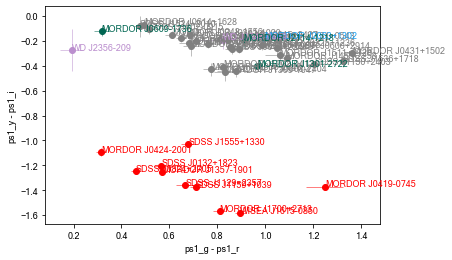

0.31957203654648675
SDSS J1524+2010
-0.45958986113700095
MORDOR J0424-2001
-0.16332275858791523
MORDOR J2053+1302
-0.049461732304201256
WD J2356-209
-1.0560993999242605
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

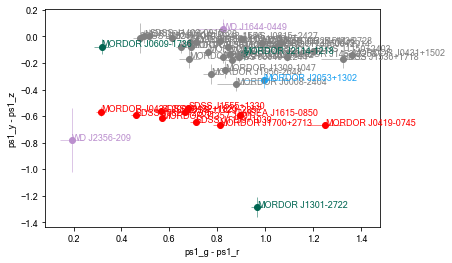

0.5776028954692491
SDSS J1524+2010
1.5170970466708857
SDSS J1129+2357
0.6686114839903466
MORDOR J2053+1302
1.310995387002615
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

-0.4772672973069982
MORDOR J1301-2722


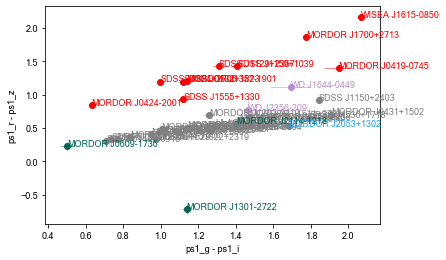

0.5867300456522311
SDSS J1524+2010
1.5139502778271585
MORDOR J0424-2001
0.9917821264997486
MORDOR J2053+1302
2.0446007212283837
WD J2356-209
0.8559483150611511
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

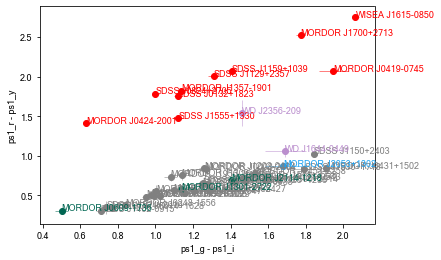

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.09019800785115573
SDSS J1524+2010
-1.3455051872157122
SDSS J1129+2357
-0.39558987099025
MORDOR J2053+1302
-0.21980447871998432
WD J2356-209
0.9399308838451963
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

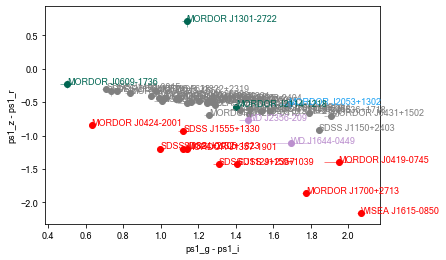

0.3427692106186813
SDSS J1524+2010
0.6738101022417987
MORDOR J0424-2001
0.5002743483456856
MORDOR J2053+1302
1.5083385606645985
WD J2356-209
1.5119013935327352
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

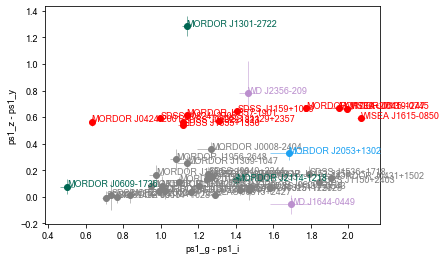

-0.10426803174036836
SDSS J1524+2010
-1.3032494292040417
MORDOR J0424-2001
-0.7360163354144489
MORDOR J2053+1302
-1.0439994374630153
WD J2356-209
-0.5200549503198504
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

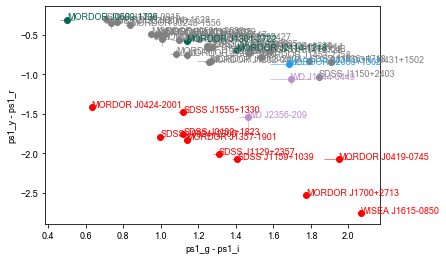

0.31957203654648675
SDSS J1524+2010
-0.45958986113700095
MORDOR J0424-2001
-0.16332275858791523
MORDOR J2053+1302
-0.049461732304201256
WD J2356-209
-1.0560993999242605
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

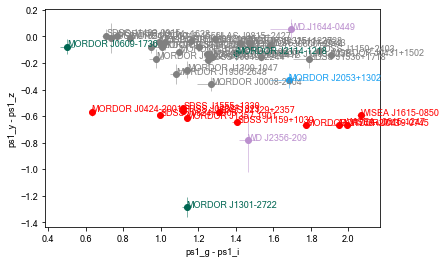

posx and posy should be finite values


0.6503105244761476
SDSS J1131+0543
0.7354467886061957
SDSS J1129+2357
0.7815072847166727
MORDOR J2053+1302
1.3904590138240487
WD J2356-209
0.2933174796777767
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

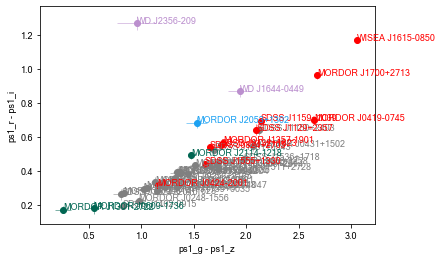

0.5867300456522311
SDSS J1524+2010
1.5139502778271585
MORDOR J0424-2001
0.9917821264997486
MORDOR J2053+1302
2.0446007212283837
WD J2356-209
0.8559483150611511
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

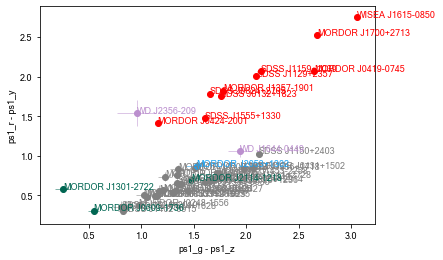

posx and posy should be finite values


-0.4006919779652587
SDSS J1131+0543
-0.5501557809738042
SDSS J1129+2357
-0.588091103955323
MORDOR J2053+1302
-1.1515408030705465
WD J2356-209
-0.07368310015622188
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

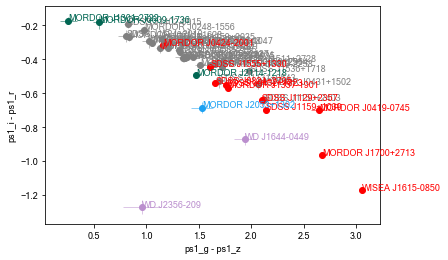

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.33024849061663947
SDSS J1524+2010
1.19198294217036
MORDOR J0424-2001
0.31730766272709887
MORDOR J2053+1302
0.7719748928960871
WD J2356-209
0.36393062107907787
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

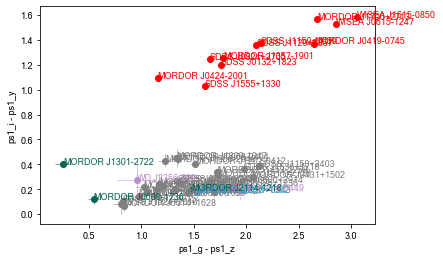

-0.10426803174036836
SDSS J1524+2010
-1.3032494292040417
MORDOR J0424-2001
-0.7360163354144489
MORDOR J2053+1302
-1.0439994374630153
WD J2356-209
-0.5200549503198504
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

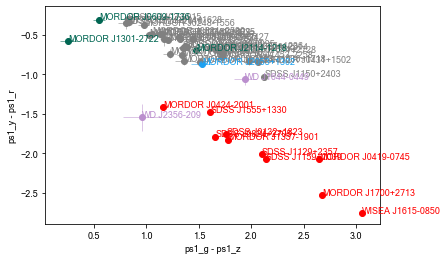

0.16264976625144062
SDSS J1524+2010
-0.991217894011245
MORDOR J0424-2001
-0.04089241051510284
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.22537455109928317
WD J2356-209
-0.02807148463391934
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

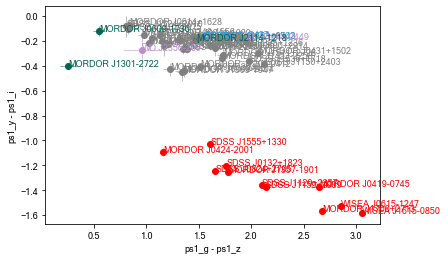

0.6503105244761476
SDSS J1131+0543
0.7354467886061957
SDSS J1129+2357
0.7815072847166727
MORDOR J2053+1302
1.3904590138240487
WD J2356-209
0.2933174796777767
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

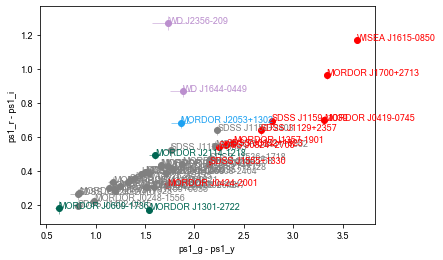

0.5776028954692491
SDSS J1524+2010
1.5170970466708857
SDSS J1129+2357


posx and posy should be finite values


0.6686114839903466
MORDOR J2053+1302
1.310995387002615
WD J2356-209
-0.4772672973069982
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

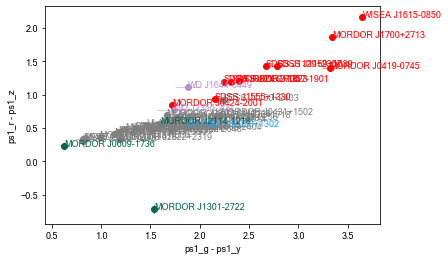

-0.4006919779652587
SDSS J1131+0543
-0.5501557809738042
SDSS J1129+2357


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.588091103955323
MORDOR J2053+1302
-1.1515408030705465
WD J2356-209
-0.07368310015622188
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

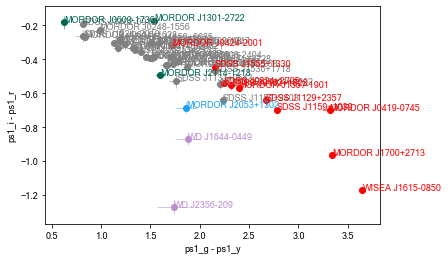

0.3210695263135117
SDSS J1524+2010
1.0962727288610004
MORDOR J0349+1241
-0.006470909217123982
MORDOR J2053+1302
0.03850492759987745
WD J2356-209
-0.648539833594798
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

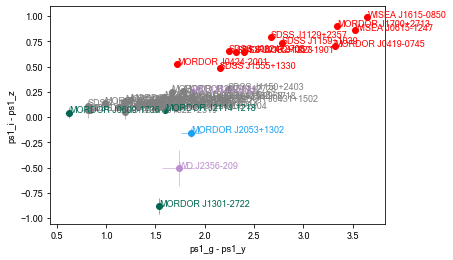

-0.09019800785115573
SDSS J1524+2010
-1.3455051872157122
SDSS J1129+2357
-0.39558987099025
MORDOR J2053+1302
-0.21980447871998432
WD J2356-209
0.9399308838451963
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

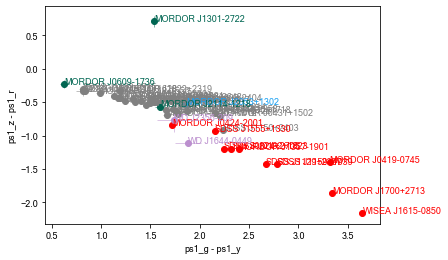

0.17666797602050746
SDSS J1524+2010
-0.8921305914514001
MORDOR J0349+1241
0.29892612447427513
MORDOR J2053+1302
1.0497048787718732
WD J2356-209
1.1134612040028014
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

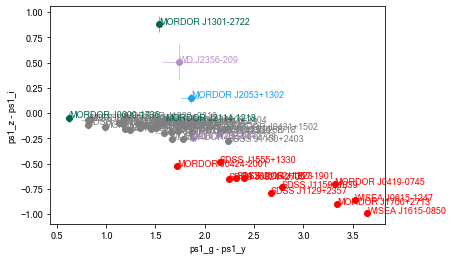

0.3210695263135117
SDSS J1524+2010
1.0962727288610004
MORDOR J0349+1241
-0.006470909217123982
MORDOR J2053+1302
0.03850492759987745
WD J2356-209
-0.648539833594798
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

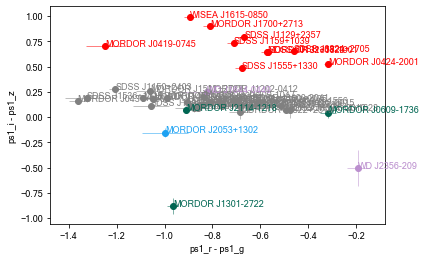

0.33024849061663947
SDSS J1524+2010
1.19198294217036
MORDOR J0424-2001
0.31730766272709887
MORDOR J2053+1302
0.7719748928960871
WD J2356-209
0.36393062107907787
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

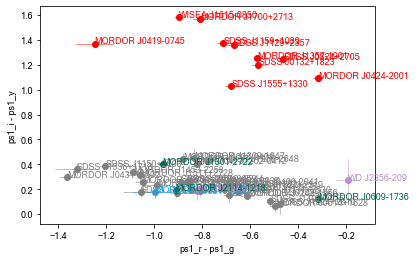

0.17666797602050746
SDSS J1524+2010
-0.8921305914514001
MORDOR J0349+1241
0.29892612447427513
MORDOR J2053+1302
1.0497048787718732
WD J2356-209
1.1134612040028014
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

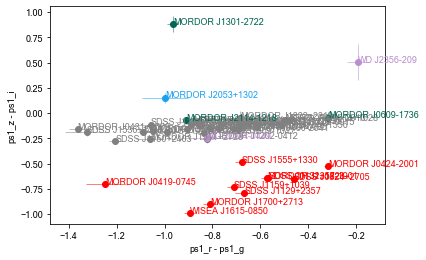

0.3427692106186813
SDSS J1524+2010
0.6738101022417987
MORDOR J0424-2001
0.5002743483456856
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


1.5083385606645985
WD J2356-209
1.5119013935327352
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

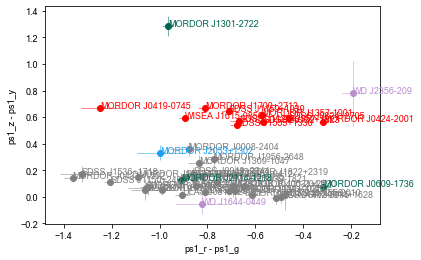

0.16264976625144062
SDSS J1524+2010
-0.991217894011245
MORDOR J0424-2001
-0.04089241051510284
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.22537455109928317
WD J2356-209
-0.02807148463391934
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

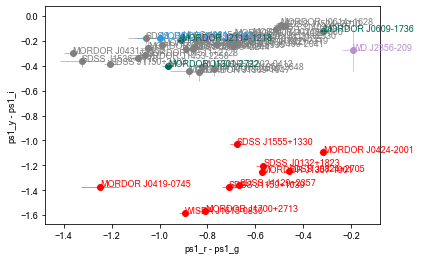

0.31957203654648675
SDSS J1524+2010
-0.45958986113700095
MORDOR J0424-2001
-0.16332275858791523
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.049461732304201256
WD J2356-209
-1.0560993999242605
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

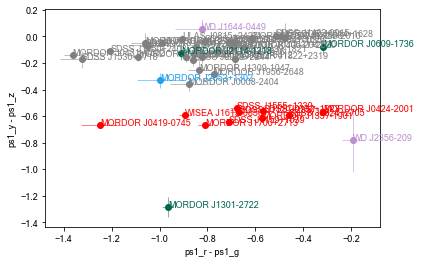

2.2697057317764333
SDSS J1536+1718
2.87901942807628
MORDOR J0419-0745
1.8384322314129724
MORDOR J2053+1302
1.5072914104537278
WD J2356-209
0.4924087300604276
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

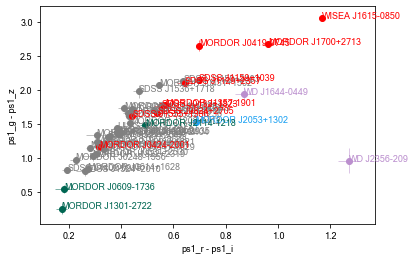

2.455836262963164
SDSS J1536+1718
3.5482928532378164
MORDOR J0419-0745
2.1665212963544995
MORDOR J2053+1302
2.2412822775731938
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


1.7622124356579107
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

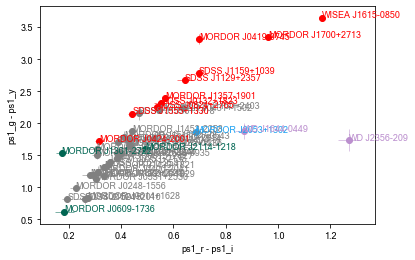

-1.6896944452255693
SDSS J1536+1718
-2.415379833398322
MORDOR J0419-0745
-1.2197686047688245
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.40750732611847384
WD J2356-209
-0.02178957316237784
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

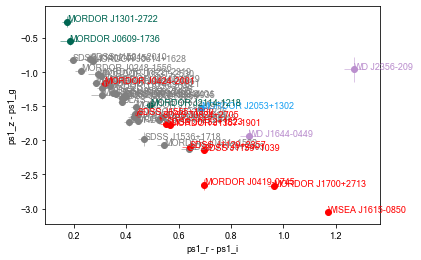

0.3427692106186813
SDSS J1524+2010
0.6738101022417987
MORDOR J0424-2001
0.5002743483456856
MORDOR J2053+1302
1.5083385606645985
WD J2356-209
1.5119013935327352
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

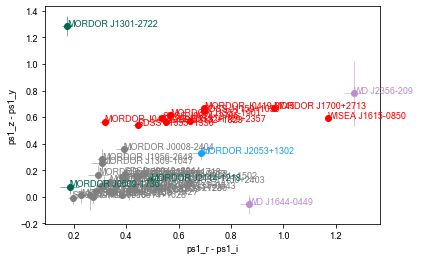

-1.8501634928962396
SDSS J1536+1718
-3.0865071040375884
MORDOR J0419-0745
-1.5552766467608983
MORDOR J2053+1302
-1.2313167519678077
WD J2356-209
-1.434789975230889
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

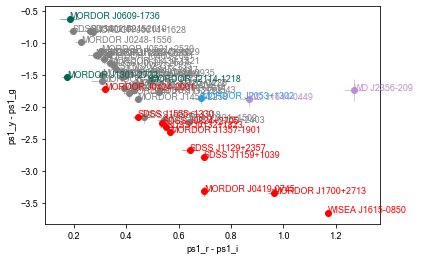

0.31957203654648675
SDSS J1524+2010
-0.45958986113700095
MORDOR J0424-2001
-0.16332275858791523
MORDOR J2053+1302
-0.049461732304201256
WD J2356-209
-1.0560993999242605
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

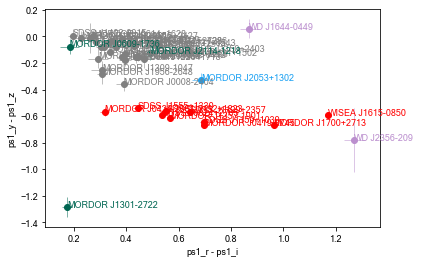

2.0636227242866214
SDSS J1536+1718
2.1784937733077236
MORDOR J0419-0745
1.9757435303740811
MORDOR J2053+1302
2.0154842614232384
WD J1644-0449


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.6093863126125134
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

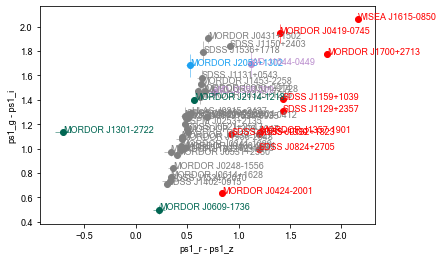

2.455836262963164
SDSS J1536+1718
3.5482928532378164
MORDOR J0419-0745
2.1665212963544995
MORDOR J2053+1302
2.2412822775731938
WD J2356-209
1.7622124356579107
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

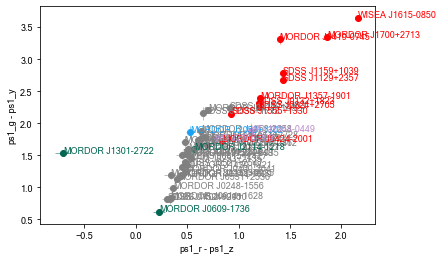

-1.5211779959283784
SDSS J1536+1718
-1.7161061412430787
MORDOR J0419-0745
-1.387854339499115
MORDOR J2053+1302
-1.3681178809107601
WD J1644-0449
-0.39261640345189003
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

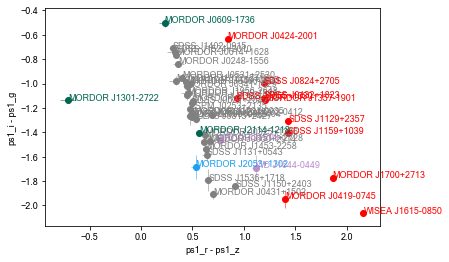

0.33024849061663947
SDSS J1524+2010
1.19198294217036
MORDOR J0424-2001


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.31730766272709887
MORDOR J2053+1302
0.7719748928960871
WD J2356-209
0.36393062107907787
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

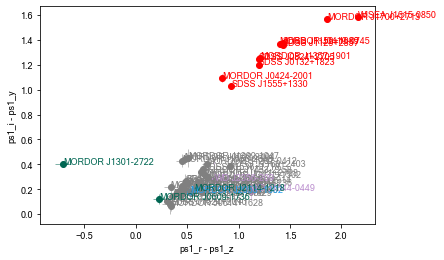

-1.8501634928962396
SDSS J1536+1718
-3.0865071040375884
MORDOR J0419-0745
-1.5552766467608983
MORDOR J2053+1302
-1.2313167519678077
WD J2356-209
-1.434789975230889
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

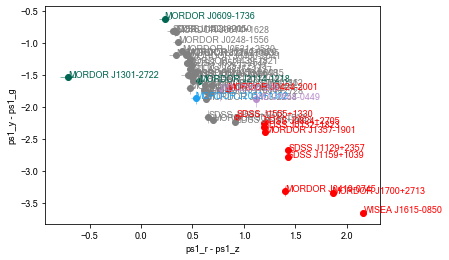

0.16264976625144062
SDSS J1524+2010
-0.991217894011245
MORDOR J0424-2001
-0.04089241051510284
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.22537455109928317
WD J2356-209
-0.02807148463391934
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

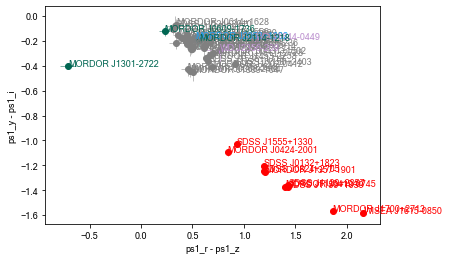

2.0636227242866214
SDSS J1536+1718
2.1784937733077236
MORDOR J0419-0745
1.9757435303740811
MORDOR J2053+1302
2.0154842614232384
WD J1644-0449


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.6093863126125134
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

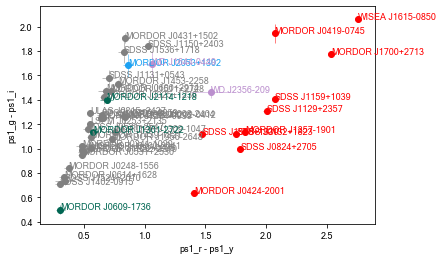

2.2697057317764333
SDSS J1536+1718
2.87901942807628
MORDOR J0419-0745
1.8384322314129724
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


1.5072914104537278
WD J2356-209
0.4924087300604276
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

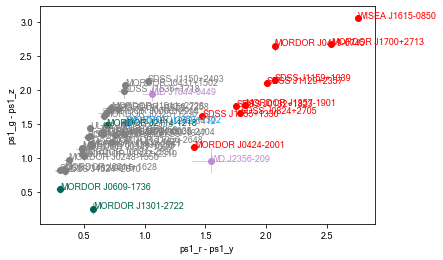

-1.5211779959283784
SDSS J1536+1718
-1.7161061412430787
MORDOR J0419-0745


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-1.387854339499115
MORDOR J2053+1302
-1.3681178809107601
WD J1644-0449
-0.39261640345189003
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

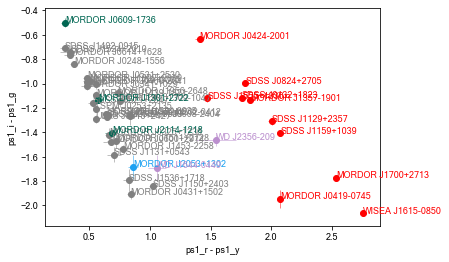

0.3210695263135117
SDSS J1524+2010
1.0962727288610004
MORDOR J0349+1241
-0.006470909217123982
MORDOR J2053+1302
0.03850492759987745
WD J2356-209
-0.648539833594798
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

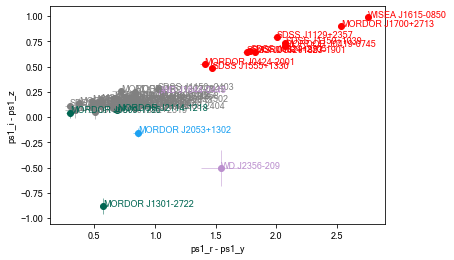

-1.6896944452255693
SDSS J1536+1718
-2.415379833398322
MORDOR J0419-0745
-1.2197686047688245
MORDOR J2053+1302
-0.40750732611847384
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.02178957316237784
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

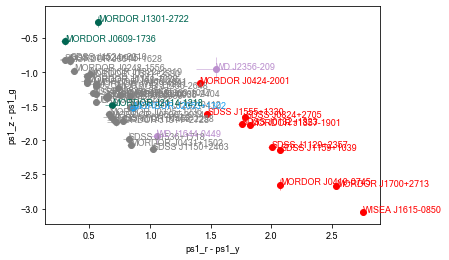

0.17666797602050746
SDSS J1524+2010
-0.8921305914514001
MORDOR J0349+1241
0.29892612447427513
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


1.0497048787718732
WD J2356-209
1.1134612040028014
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

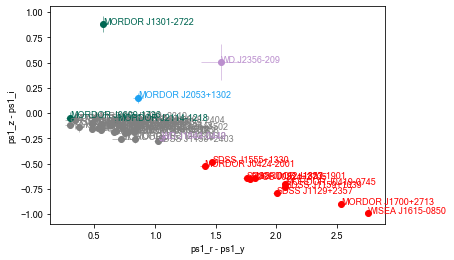

0.5776028954692491
SDSS J1524+2010
1.5170970466708857
SDSS J1129+2357
0.6686114839903466
MORDOR J2053+1302
1.310995387002615
WD J2356-209
-0.4772672973069982
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

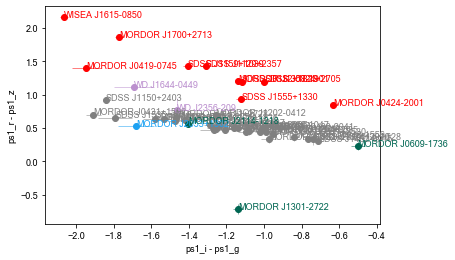

0.5867300456522311
SDSS J1524+2010
1.5139502778271585
MORDOR J0424-2001
0.9917821264997486
MORDOR J2053+1302
2.0446007212283837
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

0.8559483150611511
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

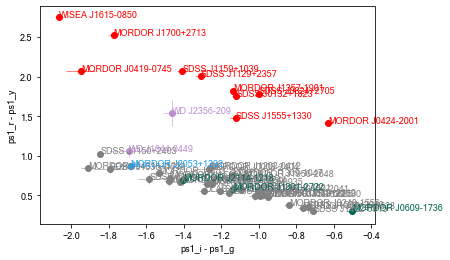

-0.09019800785115573
SDSS J1524+2010
-1.3455051872157122
SDSS J1129+2357
-0.39558987099025
MORDOR J2053+1302
-0.21980447871998432
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

0.9399308838451963
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

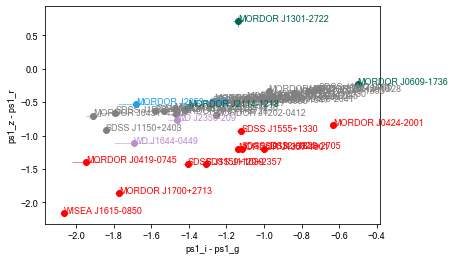

0.3427692106186813
SDSS J1524+2010
0.6738101022417987
MORDOR J0424-2001
0.5002743483456856
MORDOR J2053+1302
1.5083385606645985
WD J2356-209
1.5119013935327352
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

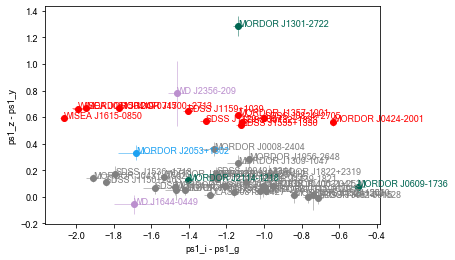

-0.10426803174036836
SDSS J1524+2010
-1.3032494292040417
MORDOR J0424-2001
-0.7360163354144489
MORDOR J2053+1302
-1.0439994374630153
WD J2356-209
-0.5200549503198504
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

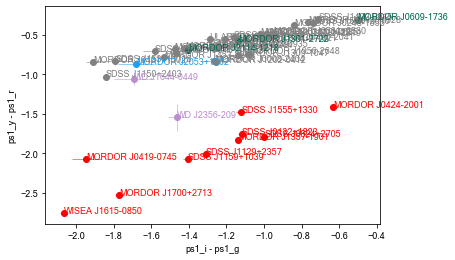

0.31957203654648675
SDSS J1524+2010
-0.45958986113700095
MORDOR J0424-2001
-0.16332275858791523
MORDOR J2053+1302
-0.049461732304201256
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-1.0560993999242605
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

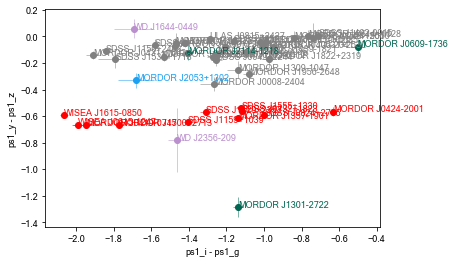

2.2697057317764333
SDSS J1536+1718
2.87901942807628
MORDOR J0419-0745
1.8384322314129724
MORDOR J2053+1302
1.5072914104537278
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.4924087300604276
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

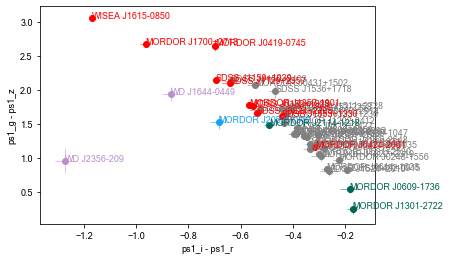

2.455836262963164
SDSS J1536+1718
3.5482928532378164
MORDOR J0419-0745
2.1665212963544995
MORDOR J2053+1302
2.2412822775731938
WD J2356-209
1.7622124356579107
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

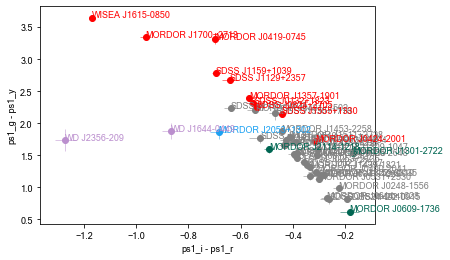

-1.6896944452255693
SDSS J1536+1718
-2.415379833398322
MORDOR J0419-0745
-1.2197686047688245
MORDOR J2053+1302
-0.40750732611847384
WD J2356-209
-0.02178957316237784
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

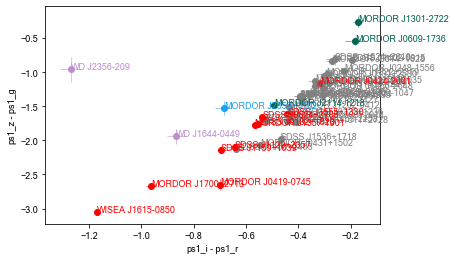

0.3427692106186813
SDSS J1524+2010
0.6738101022417987
MORDOR J0424-2001
0.5002743483456856
MORDOR J2053+1302
1.5083385606645985
WD J2356-209
1.5119013935327352
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

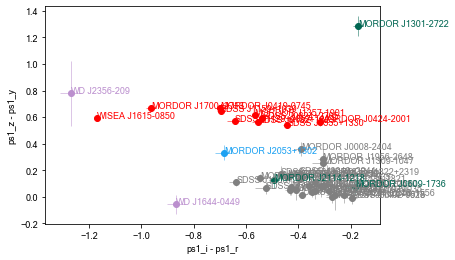

-1.8501634928962396
SDSS J1536+1718
-3.0865071040375884
MORDOR J0419-0745
-1.5552766467608983
MORDOR J2053+1302
-1.2313167519678077
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-1.434789975230889
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

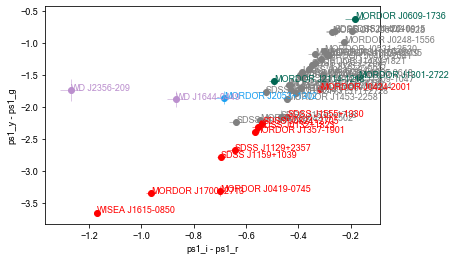

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.31957203654648675
SDSS J1524+2010
-0.45958986113700095
MORDOR J0424-2001
-0.16332275858791523
MORDOR J2053+1302
-0.049461732304201256
WD J2356-209
-1.0560993999242605
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

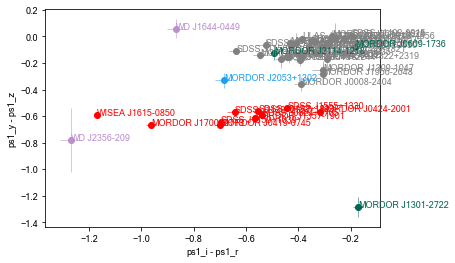

1.5958330155732992
SDSS J1536+1718
1.4823932777526097
MORDOR J0419-0745
1.286233404349173
MORDOR J2053+1302
1.1542891483101667
WD J1644-0449


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.41967742514393414
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

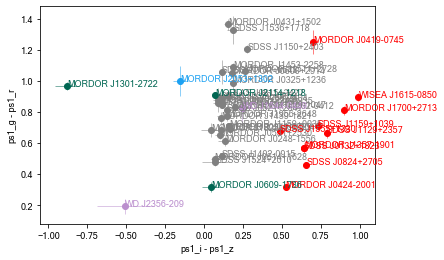

2.455836262963164
SDSS J1536+1718
3.5482928532378164
MORDOR J0419-0745
2.1665212963544995
MORDOR J2053+1302
2.2412822775731938
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

1.7622124356579107
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

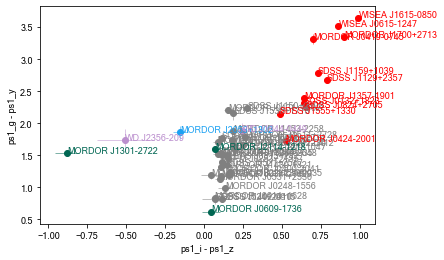

-1.0529668806670986
SDSS J1536+1718
-1.015806185137994
MORDOR J0419-0745
-0.7077660768520272
MORDOR J2053+1302
-0.49171076013703485
WD J1644-0449


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.2153247110864707
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

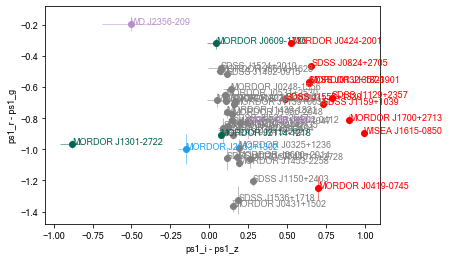

0.5867300456522311
SDSS J1524+2010
1.5139502778271585
MORDOR J0424-2001
0.9917821264997486
MORDOR J2053+1302
2.0446007212283837
WD J2356-209
0.8559483150611511
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

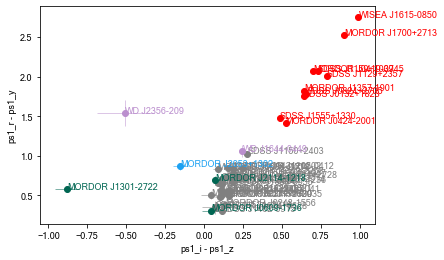

-1.8501634928962396
SDSS J1536+1718
-3.0865071040375884
MORDOR J0419-0745
-1.5552766467608983
MORDOR J2053+1302
-1.2313167519678077
WD J2356-209
-1.434789975230889
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

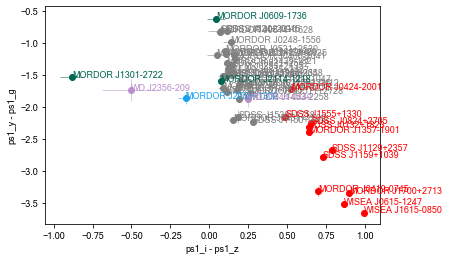

-0.10426803174036836
SDSS J1524+2010
-1.3032494292040417
MORDOR J0424-2001
-0.7360163354144489
MORDOR J2053+1302
-1.0439994374630153
WD J2356-209
-0.5200549503198504
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

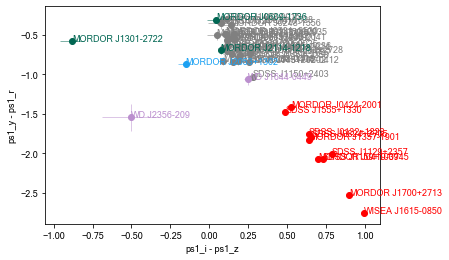

1.5958330155732992
SDSS J1536+1718
1.4823932777526097
MORDOR J0419-0745
1.286233404349173
MORDOR J2053+1302
1.1542891483101667
WD J1644-0449
0.41967742514393414
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

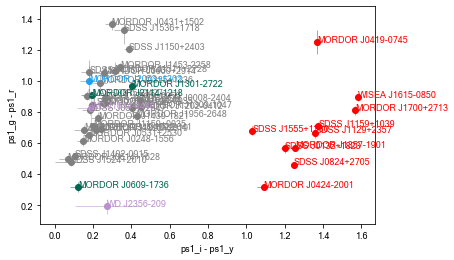

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


2.2697057317764333
SDSS J1536+1718
2.87901942807628
MORDOR J0419-0745
1.8384322314129724
MORDOR J2053+1302
1.5072914104537278
WD J2356-209
0.4924087300604276
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

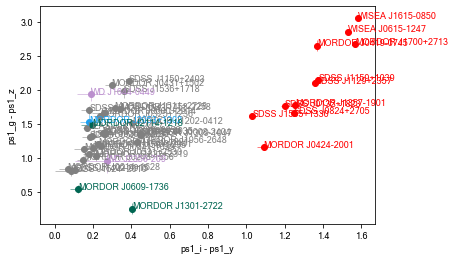

-1.0529668806670986
SDSS J1536+1718
-1.015806185137994
MORDOR J0419-0745
-0.7077660768520272
MORDOR J2053+1302
-0.49171076013703485
WD J1644-0449
-0.2153247110864707
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

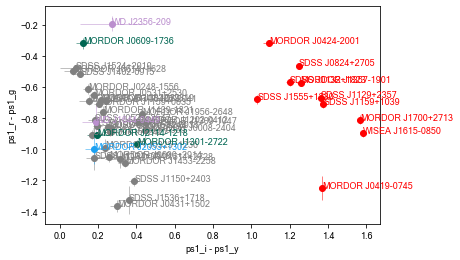

0.5776028954692491
SDSS J1524+2010
1.5170970466708857
SDSS J1129+2357
0.6686114839903466
MORDOR J2053+1302
1.310995387002615
WD J2356-209
-0.4772672973069982

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values



MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

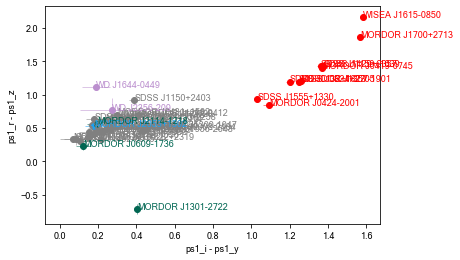

-1.6896944452255693
SDSS J1536+1718
-2.415379833398322
MORDOR J0419-0745
-1.2197686047688245
MORDOR J2053+1302
-0.40750732611847384
WD J2356-209
-0.02178957316237784
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

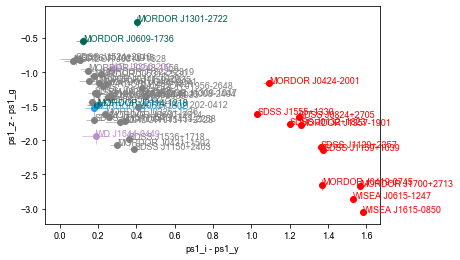

-0.09019800785115573
SDSS J1524+2010
-1.3455051872157122
SDSS J1129+2357
-0.39558987099025
MORDOR J2053+1302
-0.21980447871998432
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.9399308838451963
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

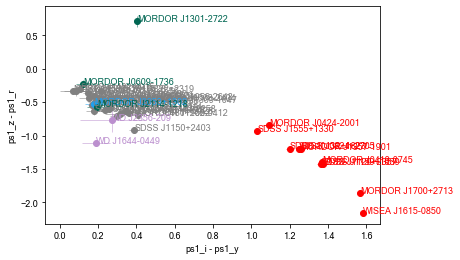

0.6503105244761476
SDSS J1131+0543
0.7354467886061957
SDSS J1129+2357
0.7815072847166727
MORDOR J2053+1302
1.3904590138240487
WD J2356-209
0.2933174796777767
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

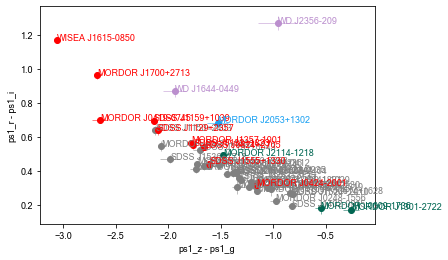

0.5867300456522311
SDSS J1524+2010
1.5139502778271585
MORDOR J0424-2001
0.9917821264997486
MORDOR J2053+1302
2.0446007212283837
WD J2356-209
0.8559483150611511
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

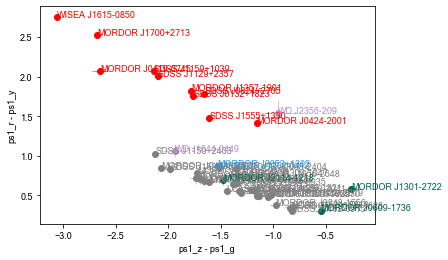

-0.4006919779652587
SDSS J1131+0543
-0.5501557809738042
SDSS J1129+2357
-0.588091103955323
MORDOR J2053+1302
-1.1515408030705465
WD J2356-209


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.07368310015622188
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

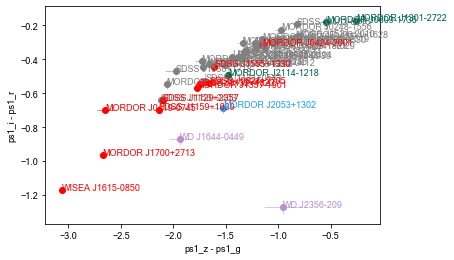

0.33024849061663947
SDSS J1524+2010
1.19198294217036
MORDOR J0424-2001
0.31730766272709887
MORDOR J2053+1302
0.7719748928960871
WD J2356-209
0.36393062107907787

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values



MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

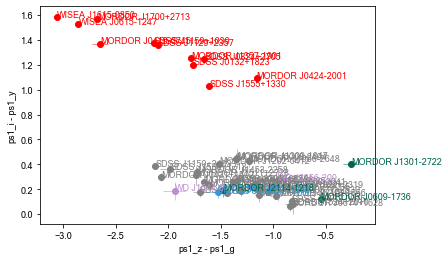

-0.10426803174036836
SDSS J1524+2010
-1.3032494292040417
MORDOR J0424-2001
-0.7360163354144489
MORDOR J2053+1302
-1.0439994374630153
WD J2356-209
-0.5200549503198504
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

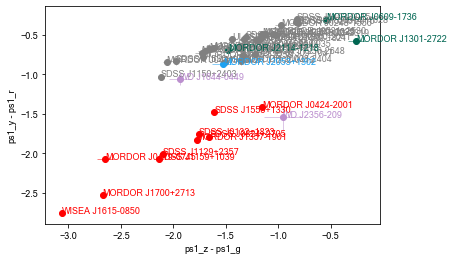

0.16264976625144062
SDSS J1524+2010
-0.991217894011245
MORDOR J0424-2001
-0.04089241051510284
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.22537455109928317
WD J2356-209
-0.02807148463391934
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

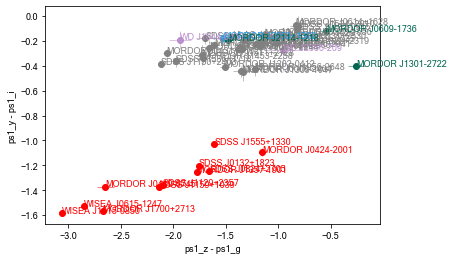

2.0636227242866214
SDSS J1536+1718
2.1784937733077236
MORDOR J0419-0745
1.9757435303740811
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


2.0154842614232384
WD J1644-0449
0.6093863126125134
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

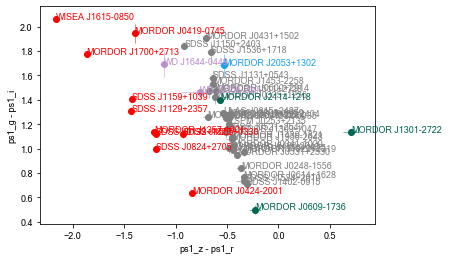

2.455836262963164
SDSS J1536+1718
3.5482928532378164
MORDOR J0419-0745
2.1665212963544995
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


2.2412822775731938
WD J2356-209
1.7622124356579107
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

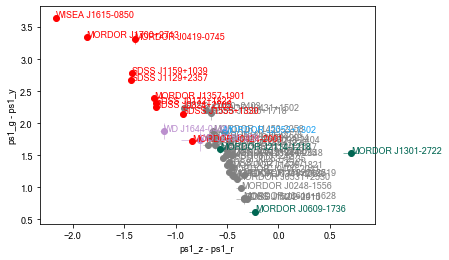

-1.5211779959283784
SDSS J1536+1718
-1.7161061412430787
MORDOR J0419-0745
-1.387854339499115
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-1.3681178809107601
WD J1644-0449
-0.39261640345189003
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

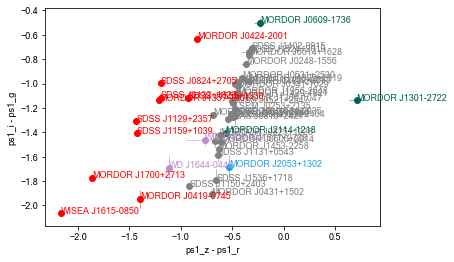

0.33024849061663947
SDSS J1524+2010
1.19198294217036
MORDOR J0424-2001
0.31730766272709887
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.7719748928960871
WD J2356-209
0.36393062107907787
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

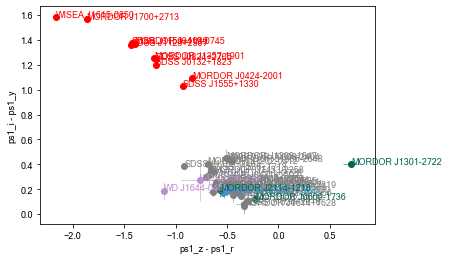

-1.8501634928962396
SDSS J1536+1718
-3.0865071040375884
MORDOR J0419-0745
-1.5552766467608983
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-1.2313167519678077
WD J2356-209
-1.434789975230889
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

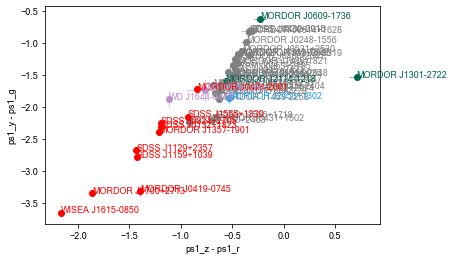

0.16264976625144062
SDSS J1524+2010
-0.991217894011245
MORDOR J0424-2001
-0.04089241051510284
MORDOR J2053+1302
0.22537455109928317
WD J2356-209
-0.02807148463391934
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

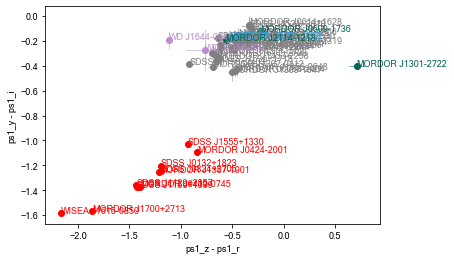

1.5958330155732992
SDSS J1536+1718
1.4823932777526097
MORDOR J0419-0745


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


1.286233404349173
MORDOR J2053+1302
1.1542891483101667
WD J1644-0449
0.41967742514393414
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

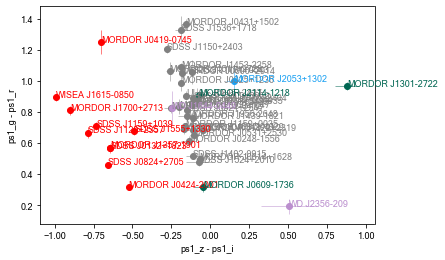

2.455836262963164
SDSS J1536+1718
3.5482928532378164
MORDOR J0419-0745


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


2.1665212963544995
MORDOR J2053+1302
2.2412822775731938
WD J2356-209
1.7622124356579107
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

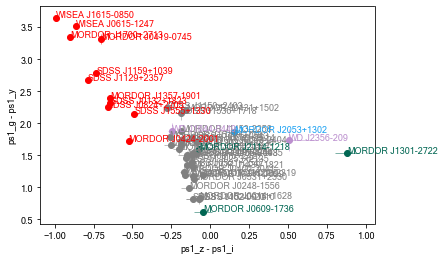

-1.0529668806670986
SDSS J1536+1718
-1.015806185137994
MORDOR J0419-0745
-0.7077660768520272
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.49171076013703485
WD J1644-0449
-0.2153247110864707
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

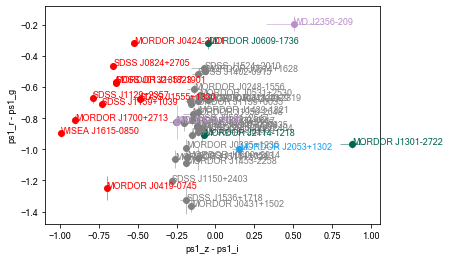

0.5867300456522311
SDSS J1524+2010
1.5139502778271585
MORDOR J0424-2001
0.9917821264997486
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


2.0446007212283837
WD J2356-209
0.8559483150611511
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

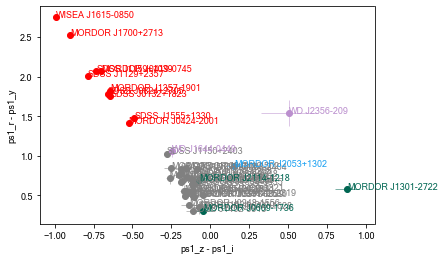

-1.8501634928962396
SDSS J1536+1718
-3.0865071040375884
MORDOR J0419-0745
-1.5552766467608983
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-1.2313167519678077
WD J2356-209
-1.434789975230889
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

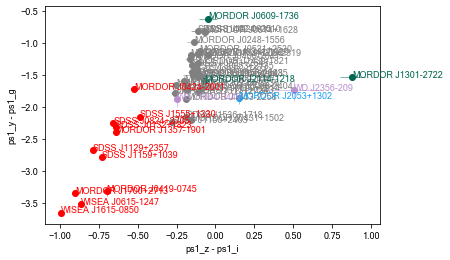

-0.10426803174036836
SDSS J1524+2010
-1.3032494292040417
MORDOR J0424-2001


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.7360163354144489
MORDOR J2053+1302
-1.0439994374630153
WD J2356-209
-0.5200549503198504
MORDOR J2114-1218


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

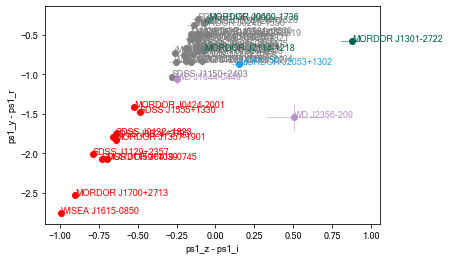

1.5958330155732992
SDSS J1536+1718
1.4823932777526097
MORDOR J0419-0745
1.286233404349173
MORDOR J2053+1302


posx and posy should be finite values


1.1542891483101667
WD J1644-0449
0.41967742514393414
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

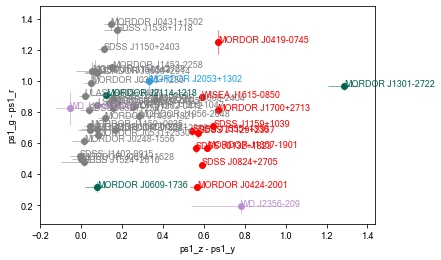

2.0636227242866214
SDSS J1536+1718
2.1784937733077236
MORDOR J0419-0745
1.9757435303740811
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


2.0154842614232384
WD J1644-0449
0.6093863126125134
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

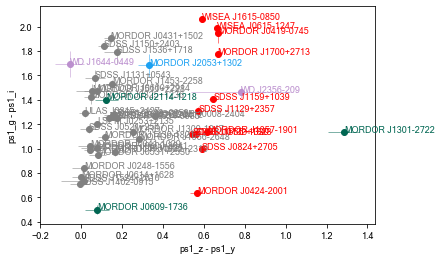

-1.0529668806670986
SDSS J1536+1718
-1.015806185137994
MORDOR J0419-0745


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.7077660768520272
MORDOR J2053+1302
-0.49171076013703485
WD J1644-0449
-0.2153247110864707
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

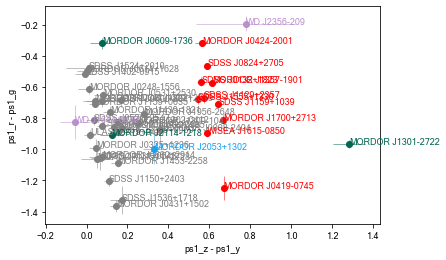

0.6503105244761476
SDSS J1131+0543
0.7354467886061957
SDSS J1129+2357


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


0.7815072847166727
MORDOR J2053+1302
1.3904590138240487
WD J2356-209
0.2933174796777767
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

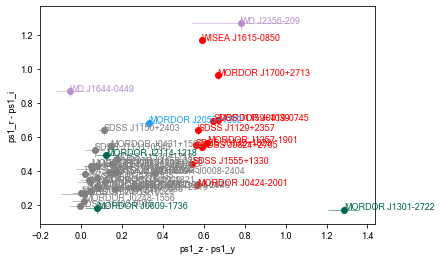

-1.5211779959283784
SDSS J1536+1718
-1.7161061412430787
MORDOR J0419-0745
-1.387854339499115
MORDOR J2053+1302
-1.3681178809107601
WD J1644-0449
-0.39261640345189003
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

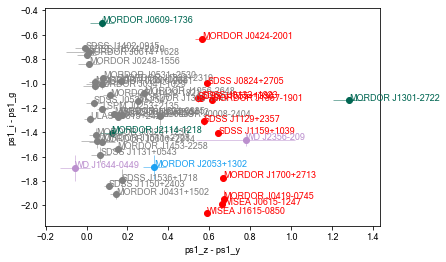

-0.4006919779652587
SDSS J1131+0543
-0.5501557809738042
SDSS J1129+2357
-0.588091103955323
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-1.1515408030705465
WD J2356-209
-0.07368310015622188
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

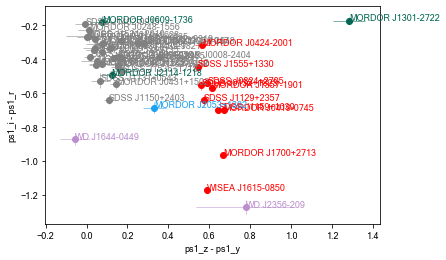

0.6503105244761476
SDSS J1131+0543
0.7354467886061957
SDSS J1129+2357
0.7815072847166727
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


1.3904590138240487
WD J2356-209
0.2933174796777767
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

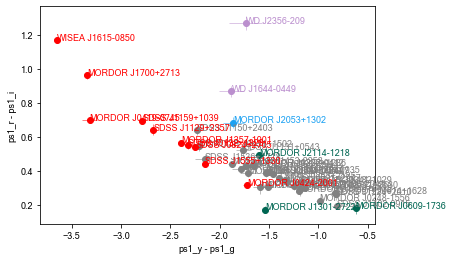

0.5776028954692491
SDSS J1524+2010
1.5170970466708857
SDSS J1129+2357
0.6686114839903466
MORDOR J2053+1302


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


1.310995387002615
WD J2356-209
-0.4772672973069982
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

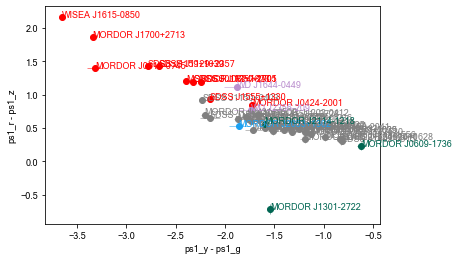

-0.4006919779652587
SDSS J1131+0543
-0.5501557809738042
SDSS J1129+2357


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


-0.588091103955323
MORDOR J2053+1302
-1.1515408030705465
WD J2356-209
-0.07368310015622188
MORDOR J0609-1736


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

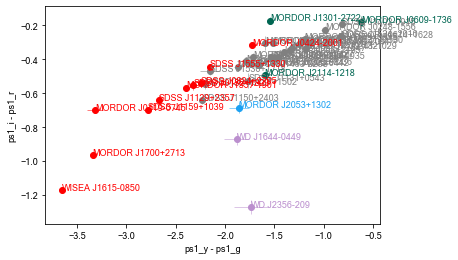

0.3210695263135117
SDSS J1524+2010
1.0962727288610004
MORDOR J0349+1241
-0.006470909217123982
MORDOR J2053+1302


posx and posy should be finite values


0.03850492759987745
WD J2356-209
-0.648539833594798
MORDOR J1301-2722


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

In [ ]:
for thing in ps1_super_list:
    for otherthing in ps1_super_list:
        if ((thing[0]==thing[1])or (otherthing[0]==otherthing[1])or (thing==otherthing) or (thing[0]in otherthing) or (thing[1] in otherthing)):
            pass
        else:
            plot_sp_types(thing,otherthing)

In [ ]:
for thing in ps1_super_list:
    for otherthing in ps1_super_list:
        if ((thing[0]==thing[1])or (otherthing[0]==otherthing[1])or (thing==otherthing)):
            pass
        else:
            plot_sp_types(thing,otherthing)

In [ ]:
print(ps1_super_list)

In [ ]:
sdss_band_list=['u','g','r','i','z']
sdss_super_list=make_super_list('sdss',sdss_band_list)
for thing in sdss_super_list:
    for otherthing in sdss_super_list:
        if ((thing[0]==thing[1])or (otherthing[0]==otherthing[1])or (thing==otherthing) or (thing[0]in otherthing) or (thing[1] in otherthing)):
            pass
        else:
            plot_sp_types(thing,otherthing)

In [ ]:
plot_sp_types([['jap3','vhs'],['hap3','vhs']],[['']])

In [ ]:
blue_patch = mpatches.Patch(color='#006652', label='blue legend') 
plt.plot([1,2,3,4],color='#006652')
plt.plot([4,6,8,4],color='blue')
plt.legend(handles=[blue_patch,blue_patch])
plt.show()